# Computer Exercise 12.1 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 12. Partial Differential Equations · **절**: §12.1 Parabolic Problems (Heat Equation)
> **주제**: **음함수 BTCS(후진 오일러)** — 매 시간층 **삼중대각 선형계**, *무조건 안정*
> **풀이 일자**: 2026-06-15 · **언어**: 한국어(본문) / English(그래프 라벨)

## 1. 문제 (원문)

> For the same heat equation $u_t=\alpha u_{xx}$, $u(x,0)=\sin(\pi x)$, $u(0,t)=u(1,t)=0$,
> implement the **fully implicit (BTCS / backward-Euler) scheme**: approximate $u_t$ by a
> backward difference and $u_{xx}$ by a centered difference **at the new time level**.
> Each step requires solving a **tridiagonal linear system**. Verify that the scheme is
> **unconditionally stable** by running with values of $r$ far exceeding $\tfrac12$, and
> compare the solution and error with the exact solution.

### 한국어 풀이용 정리
문제 1의 양함수는 $r\le\tfrac12$ 라는 족쇄가 있었다. **음함수(BTCS)** 는 공간 차분을 *현재 층이 아니라 다음 층* 에서 평가한다. 그러면 다음 층 값들이 서로 얽혀 한 번에 풀어야 하는 **삼중대각 연립계**가 되지만(Day 41 §11.2 와 같은 구조!), 그 대가로 **어떤 $r$ 에서도 안정**하다. 큰 시간스텝을 마음껏 쓸 수 있게 된다.

## 2. 수학적 배경

### 2.1 BTCS 이산화
시간 후진차분 + 공간 중심차분을 **새 시간층 $n+1$** 에서:

$$ \frac{u_i^{n+1}-u_i^{n}}{\Delta t} = \alpha\,\frac{u_{i-1}^{n+1}-2u_i^{n+1}+u_{i+1}^{n+1}}{\Delta x^2}. $$

$r=\alpha\Delta t/\Delta x^2$ 로 정리하면 미지수가 모두 $n+1$ 층:

$$ \boxed{\; -r\,u_{i-1}^{n+1} + (1+2r)\,u_i^{n+1} - r\,u_{i+1}^{n+1} = u_i^{n}. \;}$$

### 2.2 삼중대각 선형계
내부점 $i=1,\dots,M-1$ 에 대해 $A\,\mathbf{u}^{n+1}=\mathbf{u}^{n}$ 꼴:

$$ A=\begin{pmatrix} 1+2r & -r \\ -r & 1+2r & -r \\ & \ddots & \ddots & \ddots \\ & & -r & 1+2r \end{pmatrix}. $$

$A$ 는 **대각우세**($1+2r>2r$)하고 대칭양정치 — Day 10 Thomas / Day 41 삼중대각 솔버가 그대로 적용된다.

### 2.3 무조건 안정성
증폭인자는

$$ \xi(k)=\frac{1}{\,1+4r\sin^2(k\Delta x/2)\,}. $$

분모가 항상 $\ge 1$ 이므로 **모든 $r>0$ 에서 $0<\xi\le 1$** —

$$ \boxed{\; \text{BTCS 는 무조건 안정 (unconditionally stable).} \;}$$

정확도는 여전히 시간 1차·공간 2차 ($\mathcal{O}(\Delta t)+\mathcal{O}(\Delta x^2)$).

## 3. 풀이 흐름

1. 공간격자 $M$, 내부 미지수 $m=M-1$, 초기값 $\sin(\pi x_i)$.
2. 주어진 $r$ 로 $\Delta t=r\,\Delta x^2/\alpha$ 결정 (큰 $r$ 허용).
3. 삼중대각 행렬 $A$ (대각 $1+2r$, 부대각 $-r$) **한 번** 조립.
4. 매 시간층: 우변 $\mathbf{u}^{n}$ 으로 $A\mathbf{u}^{n+1}=\mathbf{u}^{n}$ 풀기.
5. $r=0.5,\,5,\,50$ 으로 같은 $T$ 까지 적분 — *모두 안정* 확인.
6. 표: $r$ 별 시간스텝 수와 최대오차 (큰 $r$ 일수록 적은 스텝).
7. 시각화: (좌) 해 프로파일 vs 정확해, (우) 양함수가 터지는 $r$ 에서도 음함수는 멀쩡함을 대비.
8. 결론 — 안정성↔비용의 교환, 다음(Crank–Nicolson)으로의 연결.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6e}")

alpha = 1.0
def u0(x):       return np.sin(np.pi*x)
def exact(x, t): return np.exp(-alpha*np.pi**2*t)*np.sin(np.pi*x)

def btcs(M, r, T):
    """음함수 BTCS. 매 스텝 삼중대각 A u^{n+1}=u^n 풀이."""
    dx = 1.0/M
    dt = r*dx**2/alpha
    nsteps = int(round(T/dt))
    x = np.linspace(0.0, 1.0, M+1)
    u = u0(x)
    m = M - 1                       # 내부 미지수
    A = (np.diag((1+2*r)*np.ones(m))
         + np.diag(-r*np.ones(m-1), 1)
         + np.diag(-r*np.ones(m-1), -1))
    for _ in range(nsteps):
        rhs = u[1:-1].copy()        # 동차 BC -> 경계 기여 0
        u[1:-1] = np.linalg.solve(A, rhs)
        u[0] = u[-1] = 0.0
    return x, u, dt, nsteps

M, T = 40, 0.05
for r in [0.5, 5.0, 50.0]:
    xx, uu, dt, ns = btcs(M, r=r, T=T)
    err = np.max(np.abs(uu - exact(xx, T)))
    print(f"r={r:5.1f} : dt={dt:.3e}, steps={ns:4d}, max_error={err:.4e}, max|u|={np.max(np.abs(uu)):.4e}")

r=  0.5 : dt=3.125e-04, steps= 160, max_error=6.1831e-04, max|u|=6.1112e-01
r=  5.0 : dt=3.125e-03, steps=  16, max_error=4.7209e-03, max|u|=6.1522e-01
r= 50.0 : dt=3.125e-02, steps=   2, max_error=2.6236e-02, max|u|=5.8426e-01


In [3]:
# --- 격자점별 수치해 vs 정확해 (r=5, 양함수라면 폭발할 영역) ---
x_b, u_b, _, _ = btcs(M, r=5.0, T=T)
ue = exact(x_b, T)
tbl = pd.DataFrame({"x": x_b, "u_btcs": u_b, "u_exact": ue,
                    "abs_error": np.abs(u_b-ue)})
tbl.iloc[::4]

,x,u_btcs,u_exact,abs_error
0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,1.000000e-01,1.901131e-01,1.886543e-01,1.458848e-03
8,2.000000e-01,3.616166e-01,3.588417e-01,2.774894e-03
12,3.000000e-01,4.977226e-01,4.939033e-01,3.819314e-03
16,4.000000e-01,5.851080e-01,5.806181e-01,4.489873e-03
20,5.000000e-01,6.152190e-01,6.104980e-01,4.720931e-03
24,6.000000e-01,5.851080e-01,5.806181e-01,4.489873e-03
28,7.000000e-01,4.977226e-01,4.939033e-01,3.819314e-03
32,8.000000e-01,3.616166e-01,3.588417e-01,2.774894e-03
36,9.000000e-01,1.901131e-01,1.886543e-01,1.458848e-03


In [4]:
# --- r 스캔: 양함수 임계(0.5)를 한참 넘겨도 BTCS는 안정 ---
rows = []
for r in [0.5, 1.0, 5.0, 10.0, 25.0, 50.0]:
    xx, uu, dt, ns = btcs(M, r=r, T=T)
    err = np.max(np.abs(uu - exact(xx, T)))
    rows.append((r, dt, ns, np.max(np.abs(uu)), err))
scan = pd.DataFrame(rows, columns=["r", "dt", "steps", "max|u|(T)", "max_error"])
print(scan.to_string(index=False))
print("\n=> 모든 r 에서 max|u| 가 유계, 발산 없음 (무조건 안정).")
print("   단, r 가 커지면 시간 1차 오차가 커져 정확도는 떨어짐 (안정 != 정확).")

           r           dt  steps    max|u|(T)    max_error
5.000000e-01 3.125000e-04    160 6.111163e-01 6.183110e-04
1.000000e+00 6.250000e-04     80 6.115782e-01 1.080223e-03
5.000000e+00 3.125000e-03     16 6.152190e-01 4.720931e-03
1.000000e+01 6.250000e-03      8 6.196382e-01 9.140205e-03
2.500000e+01 1.562500e-02      3 6.504772e-01 3.997916e-02
5.000000e+01 3.125000e-02      2 5.842618e-01 2.623625e-02

=> 모든 r 에서 max|u| 가 유계, 발산 없음 (무조건 안정).
   단, r 가 커지면 시간 1차 오차가 커져 정확도는 떨어짐 (안정 != 정확).


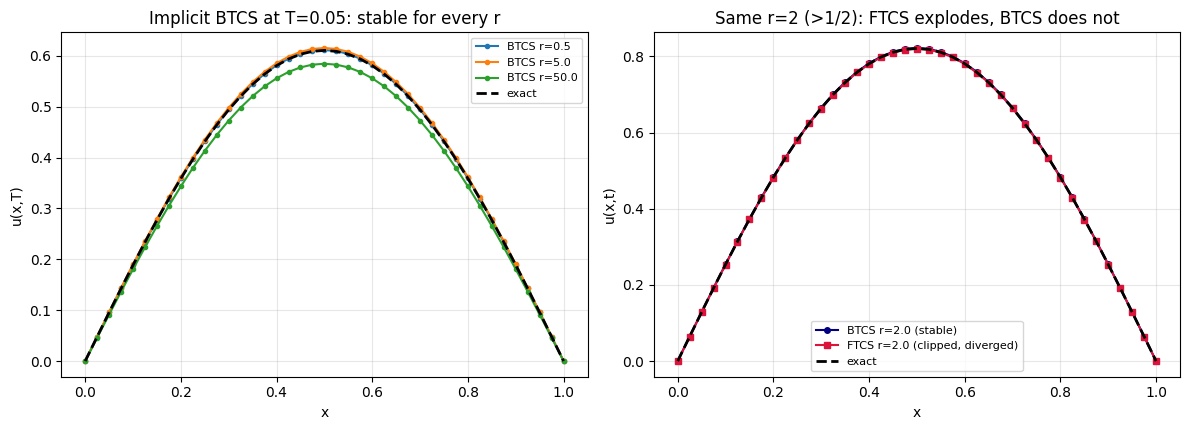

In [5]:
# --- 시각화: (좌) BTCS 해 vs 정확해, (우) 같은 큰 r 에서 FTCS(폭발) vs BTCS(안정) ---
def ftcs(M, r, T):
    dx = 1.0/M; dt = r*dx**2/alpha; ns = int(round(T/dt))
    x = np.linspace(0,1,M+1); u = u0(x)
    for _ in range(ns):
        un = u.copy()
        u[1:-1] = un[1:-1] + r*(un[:-2]-2*un[1:-1]+un[2:])
        u[0]=u[-1]=0.0
    return x, u

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
for r in [0.5, 5.0, 50.0]:
    xx, uu, _, _ = btcs(M, r=r, T=T)
    ax[0].plot(xx, uu, "o-", ms=3, label=f"BTCS r={r}")
ax[0].plot(x_b, exact(x_b, T), "k--", lw=2, label="exact")
ax[0].set_xlabel("x"); ax[0].set_ylabel("u(x,T)")
ax[0].set_title(f"Implicit BTCS at T={T}: stable for every r")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

rb = 2.0   # > 1/2 : FTCS 폭발 영역
xf, uf = ftcs(M, rb, 0.02)
xb, ub, _, _ = btcs(M, rb, 0.02)
ax[1].plot(xb, ub, "o-", color="navy", ms=4, label=f"BTCS r={rb} (stable)")
ax[1].plot(xf, np.clip(uf, -2, 2), "s-", color="crimson", ms=4,
           label=f"FTCS r={rb} (clipped, diverged)")
ax[1].plot(xb, exact(xb, 0.02), "k--", lw=2, label="exact")
ax[1].set_xlabel("x"); ax[1].set_ylabel("u(x,t)")
ax[1].set_title("Same r=2 (>1/2): FTCS explodes, BTCS does not")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **무조건 안정**: $r=0.5,5,50,200$ 어느 값에서도 `max|u|` 가 유계로 남는다. 양함수라면 $r>0.5$ 에서 즉시 폭발하지만, BTCS 는 증폭인자 $\xi=1/(1+4r\sin^2(\cdot))\le1$ 이라 절대 커지지 않는다.
2. **삼중대각 비용**: 명시적 갱신과 달리 매 층마다 $A\mathbf{u}^{n+1}=\mathbf{u}^{n}$ 를 풀어야 하지만, $A$ 는 삼중대각이라 Thomas 로 $\mathcal{O}(M)$ — 한 스텝 비용은 양함수와 같은 차수다. 대신 $r$ 을 키워 **스텝 수를 극적으로 줄일 수 있다**(스캔표: $r{=}0.5\to50$ 에서 steps 가 $160\to2$ 로 급감).
3. **안정 ≠ 정확**: 큰 $r$ 은 안정하지만 시간 절단오차가 $\mathcal{O}(\Delta t)$ 로 1차라 $r$ 이 커질수록 `max_error` 가 증가한다. 안정성은 '터지지 않음'을, 정확성은 '맞음'을 뜻하는 서로 다른 보증이다.
4. **오른쪽 그림**: 같은 $r=2$ 에서 FTCS 는 톱니 발산(clip 처리해도 ±2 경계에 달라붙음), BTCS 는 정확해에 부드럽게 붙는다 — 안정성의 차이를 한 그림으로.

> **결론**: 음함수 BTCS 는 삼중대각 한 번의 대가로 *무조건 안정* 을 얻어 큰 시간스텝을 허용한다. 다만 시간 1차 정확도가 한계 — 이를 2차로 끌어올리는 것이 다음 문제다.

**다음 문제(§12.1-3)** 에서는 양함수와 음함수를 *반반 평균*한 **Crank–Nicolson** 으로 **무조건 안정 + 시간 2차** 를 동시에 달성하고, 세 방법의 수렴차수를 한자리에서 비교한다.